
Evaluating the same model family set under the same three scenarios:

1. **Subject-specific CV** — estimate performance after per-user calibration.
2. **Universal LOSO** — estimate zero-calibration performance on an unseen user.
3. **Universal pretrain + subject calibration** — estimate a realistic online workflow where a population model is adapted using a small amount of subject-specific calibration data.

## Models compared

- **Cov + TS + LR** — strong Riemannian classical baseline.
- **EEGNetv4** — deep-learning baseline.
- **EEGSimpleConv** — lightweight deep-learning baseline.

## Channel configs

By default, this notebook runs on both:
- **8 channels**: `FC3, C3, CP3, Cz, CPz, FC4, C4, CP4`
- **22 channels**: full BNCI2014001 motor-imagery montage

## Interpretation

- **Subject-specific CV** is the calibrated-user setting.
- **LOSO** is the cold-start unseen-user setting.
- **Pretrain + calibration** is the most deployment-relevant compromise for future online use.


In [2]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import mne
import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

import torch
from skorch.classifier import NeuralNetClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit
from braindecode.models import EEGNetv4, EEGSimpleConv

moabb.set_log_level('info')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


Using device: cpu


In [ ]:

UHB_CHANNELS = ['FC3', 'C3', 'CP3', 'Cz', 'CPz', 'FC4', 'C4', 'CP4']
SFREQ = 250
DATASET = BNCI2014_001()
SUBJECTS = DATASET.subject_list

# Deep-learning input format:
# Some braindecode/skorch versions accept (n_trials, n_chans, n_times),
# others are happier with a singleton spatial dimension.
DL_ADD_SINGLETON_DIM = False

# Evaluation controls
SUBJECT_CV_SPLITS = 5
CALIBRATION_FRACTION = 0.20
CALIBRATION_RANDOM_STATE = 42

# Deep model training controls
DL_BATCH_SIZE = 32
DL_PRETRAIN_EPOCHS = 60
DL_CALIBRATION_EPOCHS = 20
DL_LR = 1e-3
DL_WEIGHT_DECAY = 1e-4
DL_PATIENCE = 8

# Run both channel settings by default
RUN_CONFIGS = ['8 Channels', '22 Channels']


In [ ]:

paradigm_all = LeftRightImagery(resample=SFREQ)
paradigm_8 = LeftRightImagery(channels=UHB_CHANNELS, resample=SFREQ)

X_all, labels_all, meta_all = paradigm_all.get_data(dataset=DATASET, subjects=SUBJECTS)
X_8, labels_8, meta_8 = paradigm_8.get_data(dataset=DATASET, subjects=SUBJECTS)

print('Subjects:', SUBJECTS)
print('X_all shape:', X_all.shape)
print('X_8 shape:', X_8.shape)
print('Unique labels:', np.unique(labels_all))


100%|#####################################| 42.3M/42.3M [00:00<00:00, 21.1GB/s]
SHA256 hash of downloaded file: d4229267ec7624fa8bd3af5cbebac17f415f7c722de6cb676748f8cb3b717d97
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|#####################################| 37.2M/37.2M [00:00<00:00, 18.6GB/s]
SHA256 hash of downloaded file: 15850d81b95fc88cc8b9589eb9b713d49fa071e28adaf32d675b3eaa30591d6e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|#####################################| 41.7M/41.7M [00:00<00:00, 17.7GB/s]
SHA256 hash of downloaded file: 81916dff2c12997974ba50ffc311da006ea66e525010d010765f0047e771c86a
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|################################

Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9]
X_all shape: (2592, 22, 1001)
X_8 shape: (2592, 8, 1001)
Unique labels: ['left_hand' 'right_hand']


In [ ]:

le = LabelEncoder()
y_all = le.fit_transform(labels_all)
y_8 = le.transform(labels_8)

CONFIGS = {
    '8 Channels': {
        'X': X_8,
        'y': y_8,
        'meta': meta_8.copy(),
        'n_chans': X_8.shape[1],
        'n_times': X_8.shape[2],
        'sfreq': SFREQ,
    },
    '22 Channels': {
        'X': X_all,
        'y': y_all,
        'meta': meta_all.copy(),
        'n_chans': X_all.shape[1],
        'n_times': X_all.shape[2],
        'sfreq': SFREQ,
    },
}

for cfg_name, cfg in CONFIGS.items():
    cfg['meta']['subject'] = cfg['meta']['subject'].astype(str)

list(CONFIGS.keys())


['8 Channels', '22 Channels']

In [ ]:

# Helpers

def prepare_dl_X(X):
    X = X.astype(np.float32)
    if DL_ADD_SINGLETON_DIM and X.ndim == 3:
        X = X[:, :, None, :]
    return X


def get_subjects(meta):
    return sorted(meta['subject'].astype(str).unique(), key=lambda x: int(x))


def positive_class_scores(estimator, X):
    if hasattr(estimator, 'predict_proba'):
        proba = estimator.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
        return np.asarray(proba).ravel()
    if hasattr(estimator, 'decision_function'):
        return np.asarray(estimator.decision_function(X)).ravel()
    preds = estimator.predict(X)
    return np.asarray(preds).ravel()


def compute_metrics(estimator, X_test, y_test):
    y_pred = estimator.predict(X_test)
    y_score = positive_class_scores(estimator, X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_score),
    }


In [ ]:
def make_cov_ts_lr(_n_chans, _n_times, _sfreq):
    return make_pipeline(
        Covariances(estimator='scm'),
        TangentSpace(metric='riemann'),
        LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')
    )


def make_eegnetv4(n_chans, n_times, sfreq):
    return NeuralNetClassifier(
        module=EEGNetv4,
        module__n_chans=n_chans,
        module__n_outputs=2,
        module__n_times=n_times,
        criterion=torch.nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        optimizer__lr=DL_LR,
        optimizer__weight_decay=DL_WEIGHT_DECAY,
        batch_size=DL_BATCH_SIZE,
        max_epochs=DL_PRETRAIN_EPOCHS,
        iterator_train__shuffle=True,
        train_split=ValidSplit(0.2, stratified=True, random_state=SEED),
        callbacks=[EarlyStopping(patience=DL_PATIENCE)],
        device=DEVICE,
        warm_start=False,
        verbose=0,
    )


def make_eegsimpleconv(n_chans, n_times, sfreq):
    return NeuralNetClassifier(
        module=EEGSimpleConv,
        module__n_chans=n_chans,
        module__n_outputs=2,
        module__n_times=n_times,
        module__sfreq=sfreq,
        criterion=torch.nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        optimizer__lr=DL_LR,
        optimizer__weight_decay=DL_WEIGHT_DECAY,
        batch_size=DL_BATCH_SIZE,
        max_epochs=DL_PRETRAIN_EPOCHS,
        iterator_train__shuffle=True,
        train_split=ValidSplit(0.2, stratified=True, random_state=SEED),
        callbacks=[EarlyStopping(patience=DL_PATIENCE)],
        device=DEVICE,
        warm_start=False,
        verbose=0,
    )


MODEL_FACTORIES = {
    'Cov + TS + LR': {'factory': make_cov_ts_lr, 'kind': 'classical'},
    'EEGNetv4': {'factory': make_eegnetv4, 'kind': 'deep'},
    'EEGSimpleConv': {'factory': make_eegsimpleconv, 'kind': 'deep'},
}

MODEL_FACTORIES.keys()


dict_keys(['Cov + TS + LR', 'EEGNetv4', 'EEGSimpleConv'])


## 1) Subject-specific CV

This evaluates each subject independently using the **same outer protocol** for all model families.

Interpretation: if you can calibrate the system on a user, this is the most relevant estimate of per-user performance.


In [ ]:

def evaluate_subject_specific_cv(cfg_name, cfg, model_factories, n_splits=5, random_state=42):
    X = cfg['X']
    y = cfg['y']
    meta = cfg['meta']
    n_chans = cfg['n_chans']
    n_times = cfg['n_times']
    sfreq = cfg['sfreq']

    subjects = get_subjects(meta)
    rows = []

    for model_name, spec in model_factories.items():
        print(f'[{cfg_name}] Subject-specific CV -> {model_name}')
        for subject in subjects:
            idx = meta['subject'] == str(subject)
            X_sub = X[idx]
            y_sub = y[idx]

            if spec['kind'] == 'deep':
                X_sub = prepare_dl_X(X_sub)

            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            fold_metrics = []

            for fold, (tr, te) in enumerate(cv.split(X_sub, y_sub), start=1):
                est = spec['factory'](n_chans, n_times, sfreq)
                est.fit(X_sub[tr], y_sub[tr])
                m = compute_metrics(est, X_sub[te], y_sub[te])
                m.update({
                    'Config': cfg_name,
                    'Protocol': 'Subject-specific CV',
                    'Model': model_name,
                    'Subject': subject,
                    'Fold': fold,
                })
                fold_metrics.append(m)

            subj_df = pd.DataFrame(fold_metrics)
            rows.append({
                'Config': cfg_name,
                'Protocol': 'Subject-specific CV',
                'Model': model_name,
                'Subject': subject,
                'Accuracy': subj_df['Accuracy'].mean(),
                'ROC_AUC': subj_df['ROC_AUC'].mean(),
            })

    return pd.DataFrame(rows)


In [10]:

subject_cv_results = []
for cfg_name in RUN_CONFIGS:
    subject_cv_results.append(
        evaluate_subject_specific_cv(cfg_name, CONFIGS[cfg_name], MODEL_FACTORIES, n_splits=SUBJECT_CV_SPLITS, random_state=SEED)
    )

df_subject_cv = pd.concat(subject_cv_results, ignore_index=True)
display(df_subject_cv.head())
print("\nMean scores by config/model:")
display(
    df_subject_cv.groupby(['Config', 'Model'])[['Accuracy', 'ROC_AUC']]
    .mean()
    .round(3)
)

[8 Channels] Subject-specific CV -> Cov + TS + LR
[8 Channels] Subject-specific CV -> EEGNetv4
[8 Channels] Subject-specific CV -> EEGSimpleConv
[22 Channels] Subject-specific CV -> Cov + TS + LR
[22 Channels] Subject-specific CV -> EEGNetv4
[22 Channels] Subject-specific CV -> EEGSimpleConv


,Config,Protocol,Model,Subject,Accuracy,ROC_AUC
0,8 Channels,Subject-specific CV,Cov + TS + LR,1,0.875257,0.949958
1,8 Channels,Subject-specific CV,Cov + TS + LR,2,0.569570,0.607474
2,8 Channels,Subject-specific CV,Cov + TS + LR,3,0.965215,0.992789
3,8 Channels,Subject-specific CV,Cov + TS + LR,4,0.770780,0.856744
4,8 Channels,Subject-specific CV,Cov + TS + LR,5,0.538052,0.577340



Mean scores by config/model:


Accuracy  ROC_AUC
Config      Model                           
22 Channels Cov + TS + LR     0.831    0.885
            EEGNetv4          0.643    0.758
            EEGSimpleConv     0.663    0.786
8 Channels  Cov + TS + LR     0.769    0.826
            EEGNetv4          0.646    0.767
            EEGSimpleConv     0.658    0.785


## 2) Universal LOSO

This is a true **leave-one-subject-out** population model test: train on all other subjects, test on the held-out subject.

Interpretation: this estimates **zero-calibration cold-start** performance for a new user.


In [ ]:

def evaluate_loso(cfg_name, cfg, model_factories):
    X = cfg['X']
    y = cfg['y']
    meta = cfg['meta']
    n_chans = cfg['n_chans']
    n_times = cfg['n_times']
    sfreq = cfg['sfreq']

    groups = meta['subject'].astype(str).values
    logo = LeaveOneGroupOut()
    rows = []

    for model_name, spec in model_factories.items():
        print(f'[{cfg_name}] LOSO -> {model_name}')
        X_model = prepare_dl_X(X) if spec['kind'] == 'deep' else X

        for split_id, (tr, te) in enumerate(logo.split(X_model, y, groups=groups), start=1):
            held_out_subject = np.unique(groups[te])[0]
            est = spec['factory'](n_chans, n_times, sfreq)
            est.fit(X_model[tr], y[tr])
            m = compute_metrics(est, X_model[te], y[te])
            m.update({
                'Config': cfg_name,
                'Protocol': 'Universal LOSO',
                'Model': model_name,
                'Subject': held_out_subject,
                'Fold': split_id,
            })
            rows.append(m)

    return pd.DataFrame(rows)


In [13]:

loso_results = []
for cfg_name in RUN_CONFIGS:
    loso_results.append(evaluate_loso(cfg_name, CONFIGS[cfg_name], MODEL_FACTORIES))

df_loso = pd.concat(loso_results, ignore_index=True)
display(df_loso.head())
print('Mean LOSO scores by config/model:')
display(df_loso.groupby(['Config', 'Model'])[['Accuracy', 'ROC_AUC']].mean().round(3))



[8 Channels] LOSO -> Cov + TS + LR
[8 Channels] LOSO -> EEGNetv4
[8 Channels] LOSO -> EEGSimpleConv
[22 Channels] LOSO -> Cov + TS + LR
[22 Channels] LOSO -> EEGNetv4
[22 Channels] LOSO -> EEGSimpleConv


,Accuracy,ROC_AUC,Config,Protocol,Model,Subject,Fold
0,0.854167,0.934703,8 Channels,Universal LOSO,Cov + TS + LR,1,1
1,0.552083,0.586130,8 Channels,Universal LOSO,Cov + TS + LR,2,2
2,0.937500,0.980083,8 Channels,Universal LOSO,Cov + TS + LR,3,3
3,0.548611,0.788146,8 Channels,Universal LOSO,Cov + TS + LR,4,4
4,0.527778,0.588059,8 Channels,Universal LOSO,Cov + TS + LR,5,5


Mean LOSO scores by config/model:


Accuracy  ROC_AUC
Config      Model                           
22 Channels Cov + TS + LR     0.654    0.769
            EEGNetv4          0.694    0.790
            EEGSimpleConv     0.615    0.749
8 Channels  Cov + TS + LR     0.685    0.779
            EEGNetv4          0.698    0.789
            EEGSimpleConv     0.647    0.755


## 3) Universal pretrain + subject-specific calibration

This section implements a more deployment-relevant workflow:

1. Train a **universal model** on all subjects except the target user.
2. Reserve a small fraction of the target user's data as **calibration**.
3. Evaluate on the remaining target-user test portion.
4. Report **before calibration** and **after calibration** scores.

### NOTE for self:

- For **deep models**, calibration is implemented as true warm-start continuation (`fit` on population data, then `partial_fit` on calibration data).
- For the **classical pipeline**, calibration is implemented by re-fitting the estimator on `population training data + subject calibration data`, which is the practical analogue for non-neural pipelines.


In [ ]:

def evaluate_pretrain_plus_calibration(cfg_name, cfg, model_factories, calibration_fraction=0.2, random_state=42):
    X = cfg['X']
    y = cfg['y']
    meta = cfg['meta']
    n_chans = cfg['n_chans']
    n_times = cfg['n_times']
    sfreq = cfg['sfreq']

    subjects = get_subjects(meta)
    rows = []

    for model_name, spec in model_factories.items():
        print(f'[{cfg_name}] Pretrain + calibration -> {model_name}')
        for subject in subjects:
            subj_mask = meta['subject'] == str(subject)
            pool_mask = ~subj_mask

            X_pool = X[pool_mask]
            y_pool = y[pool_mask]
            X_subj = X[subj_mask]
            y_subj = y[subj_mask]

            splitter = StratifiedShuffleSplit(
                n_splits=1,
                train_size=calibration_fraction,
                random_state=random_state,
            )
            calib_idx, test_idx = next(splitter.split(X_subj, y_subj))

            X_cal, y_cal = X_subj[calib_idx], y_subj[calib_idx]
            X_test, y_test = X_subj[test_idx], y_subj[test_idx]

            if spec['kind'] == 'deep':
                X_pool_m = prepare_dl_X(X_pool)
                X_cal_m = prepare_dl_X(X_cal)
                X_test_m = prepare_dl_X(X_test)

                universal = spec['factory'](n_chans, n_times, sfreq)
                universal.set_params(max_epochs=DL_PRETRAIN_EPOCHS, warm_start=False)
                universal.fit(X_pool_m, y_pool)
                before = compute_metrics(universal, X_test_m, y_test)

                calibrated = universal
                calibrated.set_params(max_epochs=DL_CALIBRATION_EPOCHS, warm_start=True)
                calibrated.partial_fit(X_cal_m, y_cal)
                after = compute_metrics(calibrated, X_test_m, y_test)
            else:
                universal = spec['factory'](n_chans, n_times, sfreq)
                universal.fit(X_pool, y_pool)
                before = compute_metrics(universal, X_test, y_test)

                calibrated = spec['factory'](n_chans, n_times, sfreq)
                X_aug = np.concatenate([X_pool, X_cal], axis=0)
                y_aug = np.concatenate([y_pool, y_cal], axis=0)
                calibrated.fit(X_aug, y_aug)
                after = compute_metrics(calibrated, X_test, y_test)

            rows.append({
                'Config': cfg_name,
                'Model': model_name,
                'Subject': subject,
                'Calibration_Fraction': calibration_fraction,
                'Accuracy_Before': before['Accuracy'],
                'ROC_AUC_Before': before['ROC_AUC'],
                'Accuracy_After': after['Accuracy'],
                'ROC_AUC_After': after['ROC_AUC'],
                'Accuracy_Gain': after['Accuracy'] - before['Accuracy'],
                'ROC_AUC_Gain': after['ROC_AUC'] - before['ROC_AUC'],
            })

    return pd.DataFrame(rows)


In [16]:

calibration_results = []
for cfg_name in RUN_CONFIGS:
    calibration_results.append(
        evaluate_pretrain_plus_calibration(
            cfg_name,
            CONFIGS[cfg_name],
            MODEL_FACTORIES,
            calibration_fraction=CALIBRATION_FRACTION,
            random_state=CALIBRATION_RANDOM_STATE,
        )
    )

df_calibration = pd.concat(calibration_results, ignore_index=True)
display(df_calibration.head())
print('Mean pretrain/calibration scores by config/model:')
display(
    df_calibration.groupby(['Config', 'Model'])[
        ['Accuracy_Before', 'Accuracy_After', 'ROC_AUC_Before', 'ROC_AUC_After', 'Accuracy_Gain', 'ROC_AUC_Gain']
    ].mean().round(3)
)


[8 Channels] Pretrain + calibration -> Cov + TS + LR
[8 Channels] Pretrain + calibration -> EEGNetv4
[8 Channels] Pretrain + calibration -> EEGSimpleConv
[22 Channels] Pretrain + calibration -> Cov + TS + LR
[22 Channels] Pretrain + calibration -> EEGNetv4
[22 Channels] Pretrain + calibration -> EEGSimpleConv


,Config,Model,Subject,Calibration_Fraction,Accuracy_Before,ROC_AUC_Before,Accuracy_After,ROC_AUC_After,Accuracy_Gain,ROC_AUC_Gain
0,8 Channels,Cov + TS + LR,1,0.2,0.857143,0.934333,0.861472,0.935832,0.004329,0.001499
1,8 Channels,Cov + TS + LR,2,0.2,0.554113,0.568366,0.558442,0.571289,0.004329,0.002924
2,8 Channels,Cov + TS + LR,3,0.2,0.943723,0.983133,0.935065,0.984708,-0.008658,0.001574
3,8 Channels,Cov + TS + LR,4,0.2,0.545455,0.797076,0.597403,0.800375,0.051948,0.003298
4,8 Channels,Cov + TS + LR,5,0.2,0.536797,0.591904,0.562771,0.590780,0.025974,-0.001124


Mean pretrain/calibration scores by config/model:


Accuracy_Before  Accuracy_After  ROC_AUC_Before  \
Config      Model                                                            
22 Channels Cov + TS + LR            0.656           0.716           0.772   
            EEGNetv4                 0.716           0.704           0.804   
            EEGSimpleConv            0.667           0.674           0.750   
8 Channels  Cov + TS + LR            0.690           0.718           0.781   
            EEGNetv4                 0.697           0.687           0.784   
            EEGSimpleConv            0.603           0.723           0.749   

                           ROC_AUC_After  Accuracy_Gain  ROC_AUC_Gain  
Config      Model                                                      
22 Channels Cov + TS + LR          0.788          0.061         0.017  
            EEGNetv4               0.812         -0.012         0.008  
            EEGSimpleConv          0.787          0.007         0.037  
8 Channels  Cov + TS + LR          0.787          0.028         0.007  
            EEGNetv4               0.791         -0.011         0.007  
            EEGSimpleConv          0.790          0.121         0.042


## 4) Aggregate summary tables

These tables are the ones you should rely on for thesis discussion because they keep the protocol explicit.


In [17]:

summary_subject = (
    df_subject_cv.groupby(['Config', 'Model'])[['Accuracy', 'ROC_AUC']]
    .mean()
    .reset_index()
    .assign(Protocol='Subject-specific CV')
)

summary_loso = (
    df_loso.groupby(['Config', 'Model'])[['Accuracy', 'ROC_AUC']]
    .mean()
    .reset_index()
    .assign(Protocol='Universal LOSO')
)

summary_cal = (
    df_calibration.groupby(['Config', 'Model'])[
        ['Accuracy_Before', 'Accuracy_After', 'ROC_AUC_Before', 'ROC_AUC_After', 'Accuracy_Gain', 'ROC_AUC_Gain']
    ]
    .mean()
    .reset_index()
)

print('Subject-specific CV summary')
display(summary_subject.round(3))

print('Universal LOSO summary')
display(summary_loso.round(3))

print('Pretrain + calibration summary')
display(summary_cal.round(3))


Subject-specific CV summary


,Config,Model,Accuracy,ROC_AUC,Protocol
0,22 Channels,Cov + TS + LR,0.831,0.885,Subject-specific CV
1,22 Channels,EEGNetv4,0.643,0.758,Subject-specific CV
2,22 Channels,EEGSimpleConv,0.663,0.786,Subject-specific CV
3,8 Channels,Cov + TS + LR,0.769,0.826,Subject-specific CV
4,8 Channels,EEGNetv4,0.646,0.767,Subject-specific CV
5,8 Channels,EEGSimpleConv,0.658,0.785,Subject-specific CV


Universal LOSO summary


,Config,Model,Accuracy,ROC_AUC,Protocol
0,22 Channels,Cov + TS + LR,0.654,0.769,Universal LOSO
1,22 Channels,EEGNetv4,0.694,0.790,Universal LOSO
2,22 Channels,EEGSimpleConv,0.615,0.749,Universal LOSO
3,8 Channels,Cov + TS + LR,0.685,0.779,Universal LOSO
4,8 Channels,EEGNetv4,0.698,0.789,Universal LOSO
5,8 Channels,EEGSimpleConv,0.647,0.755,Universal LOSO


Pretrain + calibration summary


,Config,Model,Accuracy_Before,Accuracy_After,ROC_AUC_Before,ROC_AUC_After,Accuracy_Gain,ROC_AUC_Gain
0,22 Channels,Cov + TS + LR,0.656,0.716,0.772,0.788,0.061,0.017
1,22 Channels,EEGNetv4,0.716,0.704,0.804,0.812,-0.012,0.008
2,22 Channels,EEGSimpleConv,0.667,0.674,0.750,0.787,0.007,0.037
3,8 Channels,Cov + TS + LR,0.690,0.718,0.781,0.787,0.028,0.007
4,8 Channels,EEGNetv4,0.697,0.687,0.784,0.791,-0.011,0.007
5,8 Channels,EEGSimpleConv,0.603,0.723,0.749,0.790,0.121,0.042



## 5) Visualization

The plots below are split by protocol so that you do not accidentally compare within-subject scores against LOSO scores in a single bar chart.


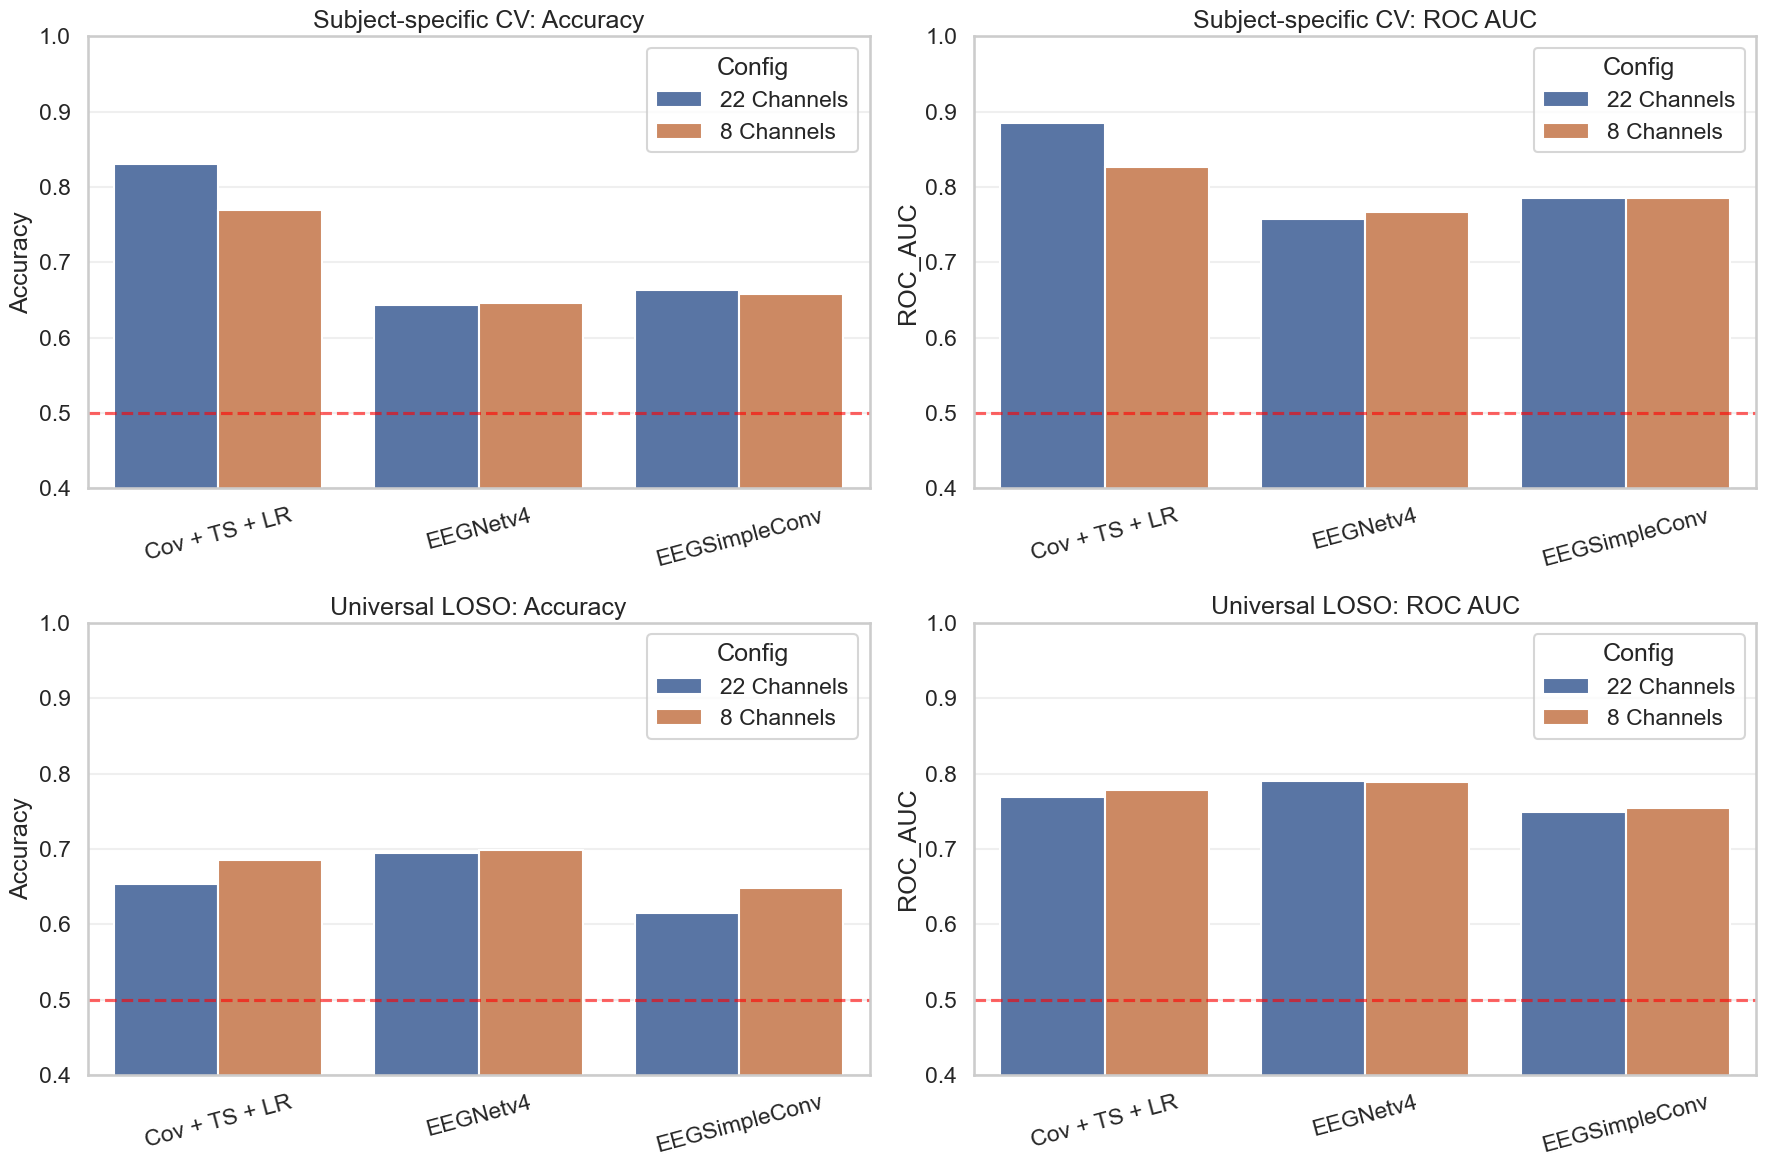

In [18]:

sns.set_theme(style='whitegrid', context='talk')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Subject-specific accuracy
ax = axes[0, 0]
sns.barplot(data=summary_subject, x='Model', y='Accuracy', hue='Config', ax=ax)
ax.set_title('Subject-specific CV: Accuracy')
ax.set_ylim(0.4, 1.0)
ax.tick_params(axis='x', rotation=15)

# Subject-specific AUC
ax = axes[0, 1]
sns.barplot(data=summary_subject, x='Model', y='ROC_AUC', hue='Config', ax=ax)
ax.set_title('Subject-specific CV: ROC AUC')
ax.set_ylim(0.4, 1.0)
ax.tick_params(axis='x', rotation=15)

# LOSO accuracy
ax = axes[1, 0]
sns.barplot(data=summary_loso, x='Model', y='Accuracy', hue='Config', ax=ax)
ax.set_title('Universal LOSO: Accuracy')
ax.set_ylim(0.4, 1.0)
ax.tick_params(axis='x', rotation=15)

# LOSO AUC
ax = axes[1, 1]
sns.barplot(data=summary_loso, x='Model', y='ROC_AUC', hue='Config', ax=ax)
ax.set_title('Universal LOSO: ROC AUC')
ax.set_ylim(0.4, 1.0)
ax.tick_params(axis='x', rotation=15)

for ax in axes.flat:
    ax.axhline(0.5, ls='--', c='red', alpha=0.6)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


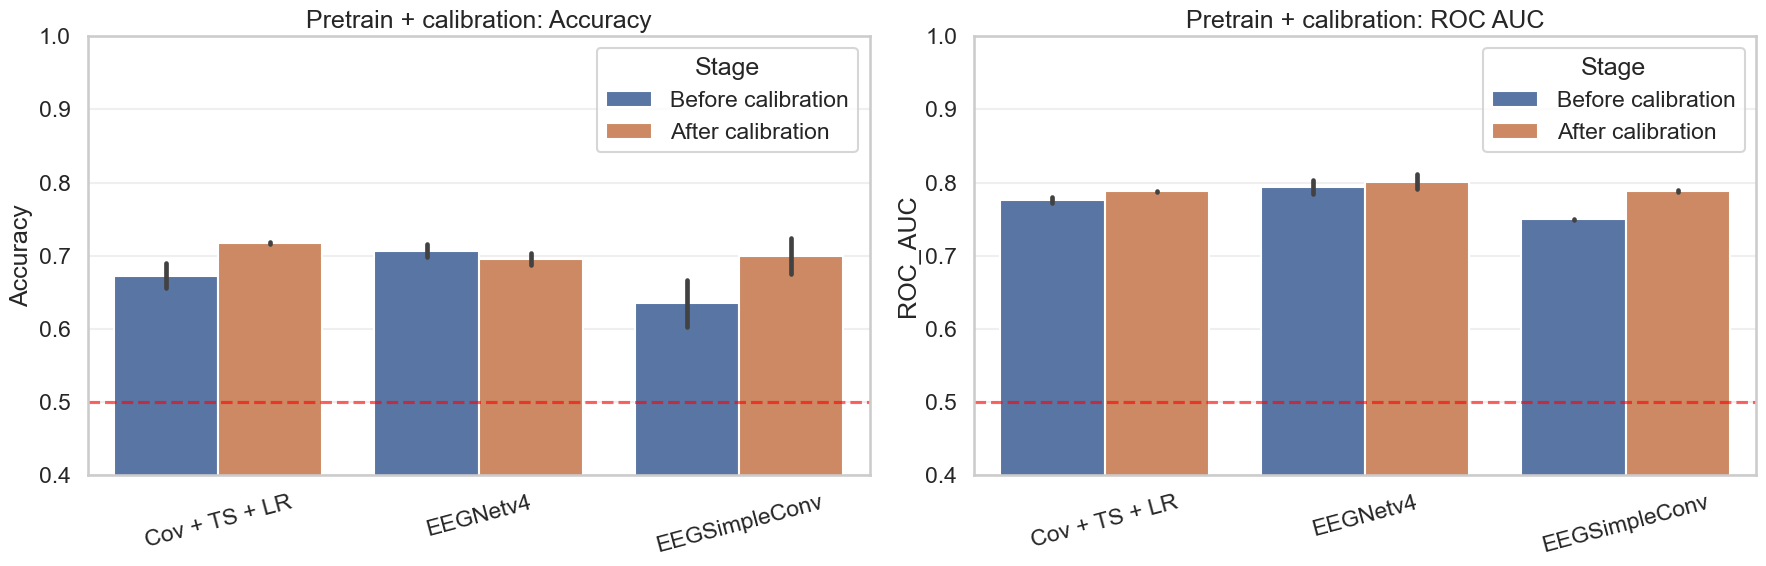

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cal_acc = summary_cal.melt(
    id_vars=['Config', 'Model'],
    value_vars=['Accuracy_Before', 'Accuracy_After'],
    var_name='Stage', value_name='Accuracy'
)
cal_acc['Stage'] = cal_acc['Stage'].map({
    'Accuracy_Before': 'Before calibration',
    'Accuracy_After': 'After calibration'
})

cal_auc = summary_cal.melt(
    id_vars=['Config', 'Model'],
    value_vars=['ROC_AUC_Before', 'ROC_AUC_After'],
    var_name='Stage', value_name='ROC_AUC'
)
cal_auc['Stage'] = cal_auc['Stage'].map({
    'ROC_AUC_Before': 'Before calibration',
    'ROC_AUC_After': 'After calibration'
})

sns.barplot(data=cal_acc, x='Model', y='Accuracy', hue='Stage', ax=axes[0])
axes[0].set_title('Pretrain + calibration: Accuracy')
axes[0].set_ylim(0.4, 1.0)
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(0.5, ls='--', c='red', alpha=0.6)
axes[0].set_xlabel('')

sns.barplot(data=cal_auc, x='Model', y='ROC_AUC', hue='Stage', ax=axes[1])
axes[1].set_title('Pretrain + calibration: ROC AUC')
axes[1].set_ylim(0.4, 1.0)
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(0.5, ls='--', c='red', alpha=0.6)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


In [ ]:

output_dir = Path('output_tables')
output_dir.mkdir(exist_ok=True)

summary_subject.to_csv(output_dir / 'subject_specific_summary.csv', index=False)
summary_loso.to_csv(output_dir / 'loso_summary.csv', index=False)
summary_cal.to_csv(output_dir / 'pretrain_calibration_summary.csv', index=False)

df_subject_cv.to_csv(output_dir / 'subject_specific_per_subject.csv', index=False)
df_loso.to_csv(output_dir / 'loso_per_subject.csv', index=False)
df_calibration.to_csv(output_dir / 'pretrain_calibration_per_subject.csv', index=False)

print('Saved CSV outputs to:', output_dir.resolve())


Saved CSV outputs to: C:\Users\Mykyta\Documents\GitHub\brainwave-surfers\PythonBCI\src\notebooks\output_tables
